# Thực hành về nhà: Mô hình sinh DCGAN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import Variable
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary

# Re-initializing setup
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
width = 28
height = 28
channels = 1

<H2>1. Load dữ liệu MNIST</H2>


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

batch_size = 32

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
print("Data loaded and trainloader initialized.")

Data loaded and trainloader initialized.


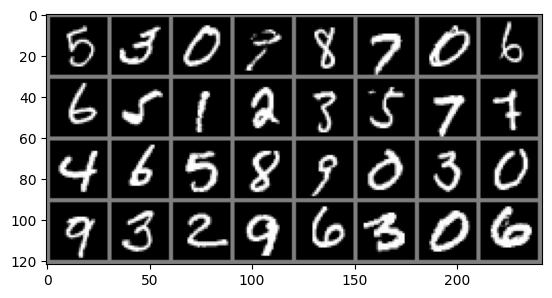

    5     3     0     9     8     7     0     6     6     5     1     2     3     5     7     7     4     6     5     8     9     0     3     0     9     3     2     9     6     3     0     6


In [ ]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % labels[j].item() for j in range(batch_size)))

<H2>2. Generator</H2>

Lập trình mạng generator.
    
    + Đầu vào là vector ngẫu nhiên 100 chiều.
    + Đầu ra là một ảnh fake với giá trị pixel trong khoảng [-1, 1].

Các thông số của mạng như sau

- Dense(7*7*128, kernel_initializer='glorot_normal',input_shape=(inidim,)))
- LeakyReLU(0.2))
- Reshape( [7, 7, 128])
- UpSampling2D(size=(2, 2))
- Conv2D(64, (5, 5), padding='same', kernel_initializer='glorot_uniform')
- LeakyReLU(0.2)
- UpSampling2D(size=(2, 2))
- Conv2D(1, (5, 5), padding='same', kernel_initializer='glorot_uniform'))
- Activation('tanh')



In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(100, 7 * 7 * 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Unflatten(1, (128, 7, 7)),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 5, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 1, 5, padding=2),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

G = Generator().cuda()
summary(G, (100, ), batch_size=-1, device='cuda')
print("_____________________ Generator Created_____________________")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 6272]         633,472
         LeakyReLU-2                 [-1, 6272]               0
         Unflatten-3            [-1, 128, 7, 7]               0
          Upsample-4          [-1, 128, 14, 14]               0
            Conv2d-5           [-1, 64, 14, 14]         204,864
         LeakyReLU-6           [-1, 64, 14, 14]               0
          Upsample-7           [-1, 64, 28, 28]               0
            Conv2d-8            [-1, 1, 28, 28]           1,601
              Tanh-9            [-1, 1, 28, 28]               0
Total params: 839,937
Trainable params: 839,937
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.92
Params size (MB): 3.20
Estimated Total Size (MB): 4.13
-------------------------------------------

<H2>4. Discriminator</H2>

Khai báo mạng discriminator

    + Đầu vào là một ảnh 28x28
    + Đầu ra là một xác suất cho ta biết ảnh đấy là real hay fake với giá trị trong miền [0, 1]

Thông số của mạng như sau:

-  Conv2D(64, (5, 5), strides=(2, 2), padding= 'same',input_shape=shp)
-  LeakyReLU(0.2)
-  Dropout(dropout_rate)
-  Conv2D(128, (5, 5), strides=(2, 2), padding = 'same')
-  LeakyReLU(0.2)
-  Dropout(dropout_rate)
-  Flatten()
-  Dense(1,activation='sigmoid')

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(64, 128, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)

D = Discriminator().cuda()
summary(D, (1, 28, 28), batch_size=-1, device='cuda')
print("____________________ Discriminator Created____________________")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 14, 14]           1,664
         LeakyReLU-2           [-1, 64, 14, 14]               0
         Dropout2d-3           [-1, 64, 14, 14]               0
            Conv2d-4            [-1, 128, 7, 7]         204,928
         LeakyReLU-5            [-1, 128, 7, 7]               0
         Dropout2d-6            [-1, 128, 7, 7]               0
           Flatten-7                 [-1, 6272]               0
            Linear-8                    [-1, 1]           6,273
           Sigmoid-9                    [-1, 1]               0
Total params: 212,865
Trainable params: 212,865
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.48
Params size (MB): 0.81
Estimated Total Size (MB): 1.29
-------------------------------------------

<h2>5. GAN model</h2>

Chúng ta ghép hai mạng vào với nhau mang generator trước, mạng disciminator sau

Lập trình hàm để ghép mạng

In [ ]:
epochs = 100
lr = 0.0002
b1 = 0.5
b2 = 0.999

adversarial_loss = torch.nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(b1, b2))
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(b1, b2))

losses_G = []
losses_D = []
samples = []

In [ ]:
# Re-running the training loop with fixed references
for epoch in range(epochs):
    for (i, (imgs, _)) in enumerate(trainloader, start=1):
        valid = Variable(torch.cuda.FloatTensor(imgs.size(0), 1).fill_(1.0), requires_grad=False)
        fake = Variable(torch.cuda.FloatTensor(imgs.size(0), 1).fill_(0.0), requires_grad=False)
        real_imgs = Variable(imgs.type(torch.cuda.FloatTensor))

        # Train Generator
        optimizer_G.zero_grad()
        z = Variable(torch.cuda.FloatTensor(np.random.normal(0, 1, (imgs.shape[0], 100))))
        gen_imgs = G(z)
        g_loss = adversarial_loss(D(gen_imgs), valid)
        g_loss.backward()
        optimizer_G.step()

        # Train Discriminator
        optimizer_D.zero_grad()
        real_loss = adversarial_loss(D(real_imgs), valid)
        fake_loss = adversarial_loss(D(gen_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        if i == len(trainloader):
            print("[Epoch %d/%d] [D loss: %f] [G loss: %f]" % (epoch, epochs, d_loss.item(), g_loss.item()))
            losses_G.append(g_loss.item())
            losses_D.append(d_loss.item())
            if epoch % 10 == 0:
                samples.append(gen_imgs.detach())

[Epoch 0/100] [D loss: 0.673092] [G loss: 0.687532]
[Epoch 1/100] [D loss: 0.671182] [G loss: 0.687950]
[Epoch 2/100] [D loss: 0.674423] [G loss: 0.684137]
[Epoch 3/100] [D loss: 0.668240] [G loss: 0.685580]
[Epoch 4/100] [D loss: 0.670310] [G loss: 0.686044]
[Epoch 5/100] [D loss: 0.675950] [G loss: 0.688350]
[Epoch 6/100] [D loss: 0.667418] [G loss: 0.685782]
[Epoch 7/100] [D loss: 0.683775] [G loss: 0.687049]
[Epoch 8/100] [D loss: 0.670554] [G loss: 0.686675]
[Epoch 9/100] [D loss: 0.674498] [G loss: 0.684469]
[Epoch 10/100] [D loss: 0.676152] [G loss: 0.684120]
[Epoch 11/100] [D loss: 0.671648] [G loss: 0.685705]
[Epoch 12/100] [D loss: 0.673375] [G loss: 0.683377]
[Epoch 13/100] [D loss: 0.674883] [G loss: 0.685772]
[Epoch 14/100] [D loss: 0.675818] [G loss: 0.687859]
[Epoch 15/100] [D loss: 0.670939] [G loss: 0.687876]
[Epoch 16/100] [D loss: 0.674527] [G loss: 0.685922]
[Epoch 17/100] [D loss: 0.679516] [G loss: 0.684964]
[Epoch 18/100] [D loss: 0.670581] [G loss: 0.684553]
[Ep

In [ ]:
torch.save(G.state_dict(), 'generator.pth')
torch.save(D.state_dict(), 'discriminator.pth')
print("Checkpoints saved successfully.")

Checkpoints saved successfully.


### Insights on the Training Progress
As the training continues, the **Generator loss (G loss)** and **Discriminator loss (D loss)** will fluctuate. This is normal in GANs as they are in a constant competition. Ideally, we want to see the generated samples in the visualization cell start to resemble recognizable digits as we move past epoch 20-30.

### Vẽ đồ thị loss khi huấn luyện

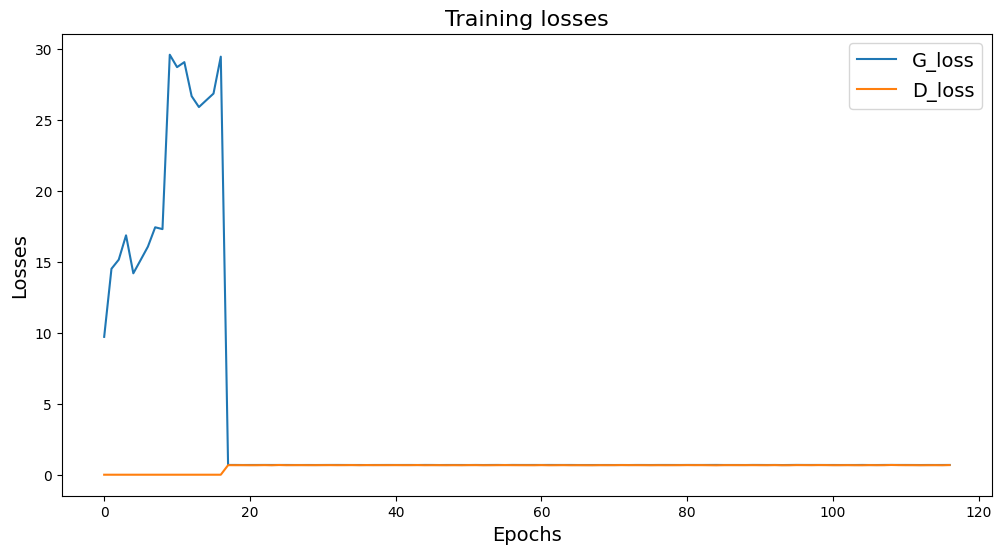

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(losses_G, label="G_loss")
plt.plot(losses_D, label="D_loss")
plt.title("Training losses", fontsize=16)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Losses", fontsize=14)
plt.legend(loc="upper right", fontsize=14)
plt.show()

### Trực quan dữ liệu sinh ra thử mạng học được

    ____________________ Epoch = 0 ____________________


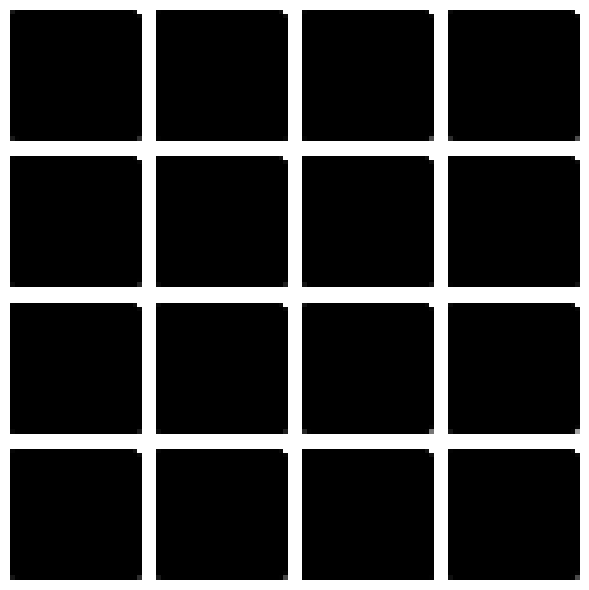



    ____________________ Epoch = 10 ____________________


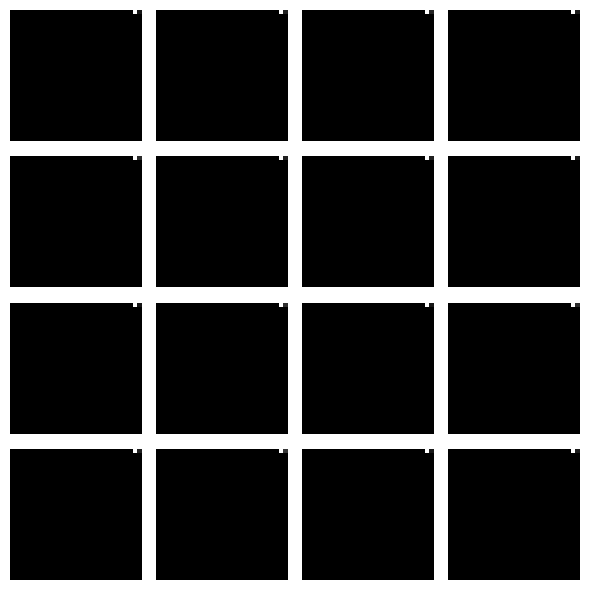



    ____________________ Epoch = 20 ____________________


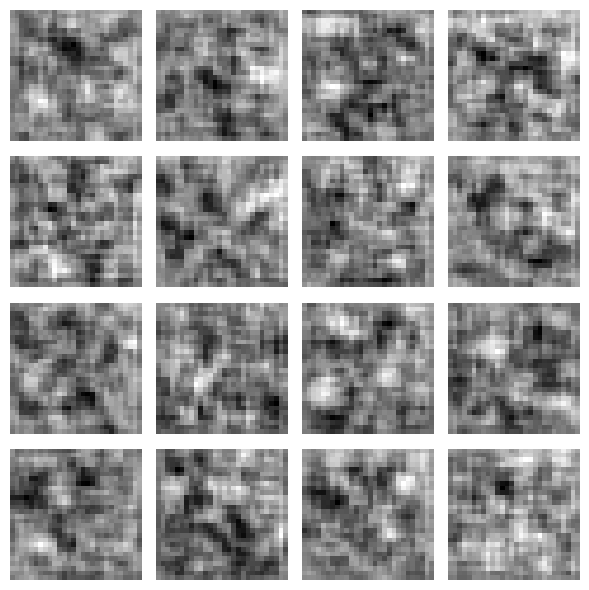



    ____________________ Epoch = 30 ____________________


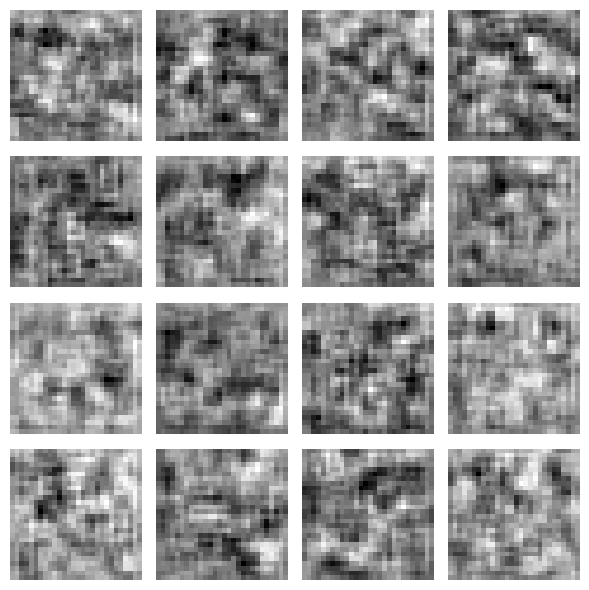



    ____________________ Epoch = 40 ____________________


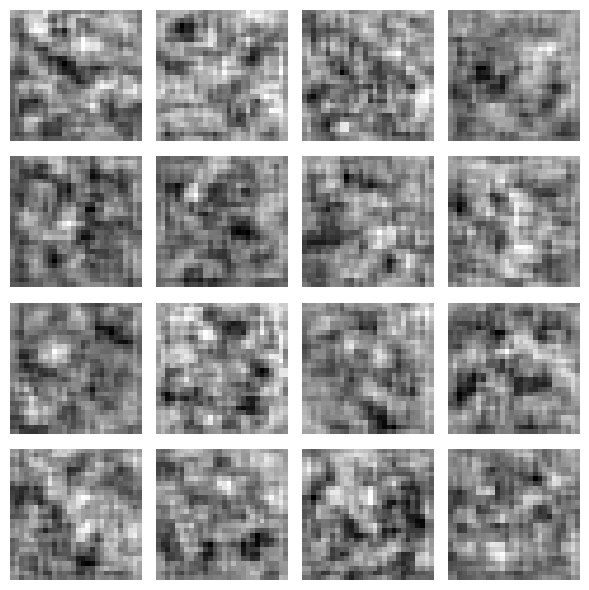



    ____________________ Epoch = 50 ____________________


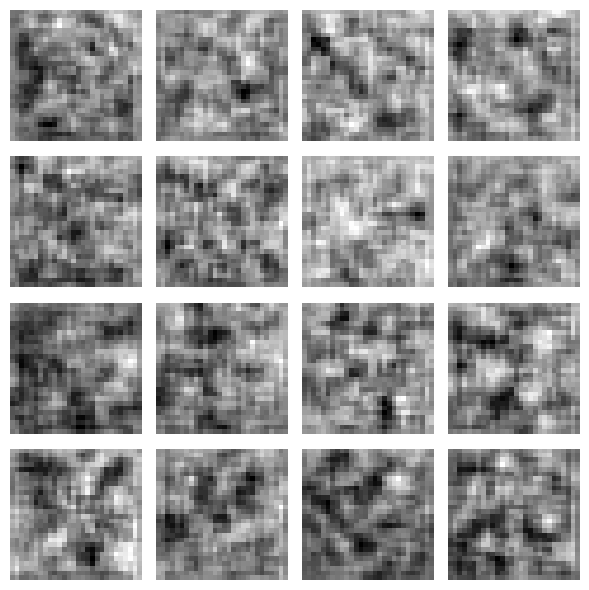



    ____________________ Epoch = 60 ____________________


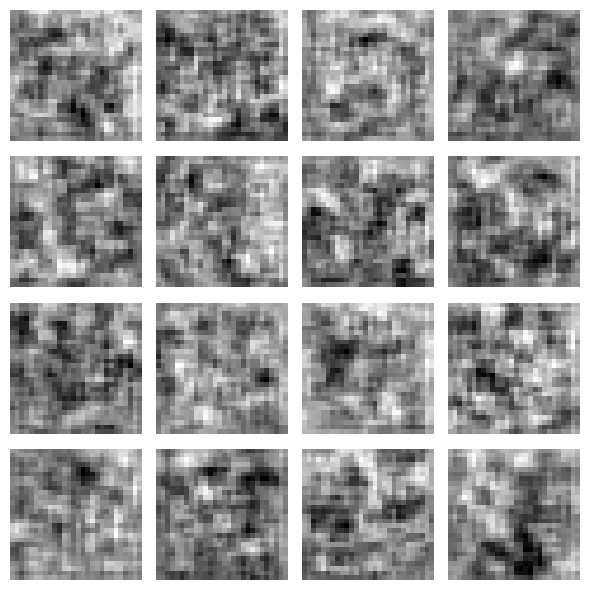



    ____________________ Epoch = 70 ____________________


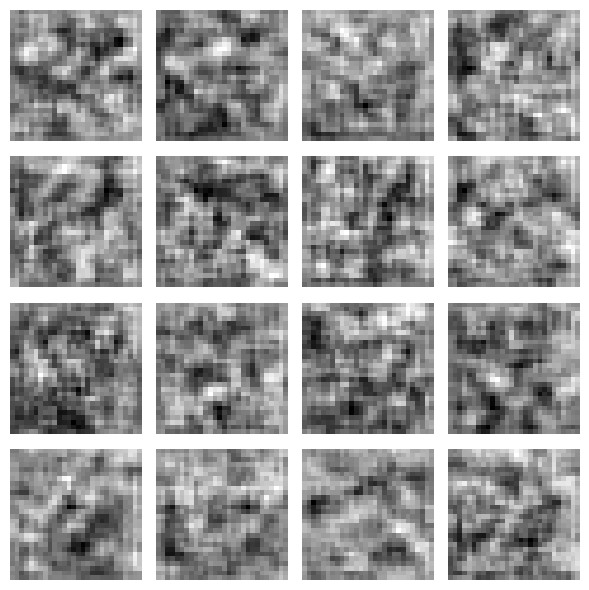



    ____________________ Epoch = 80 ____________________


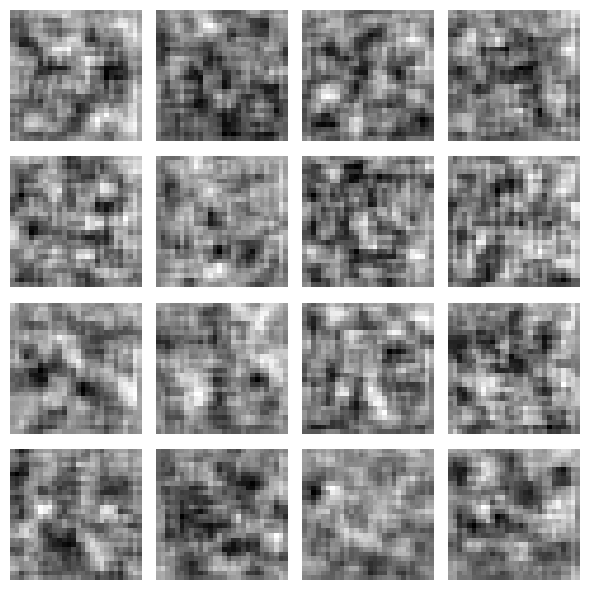



    ____________________ Epoch = 90 ____________________


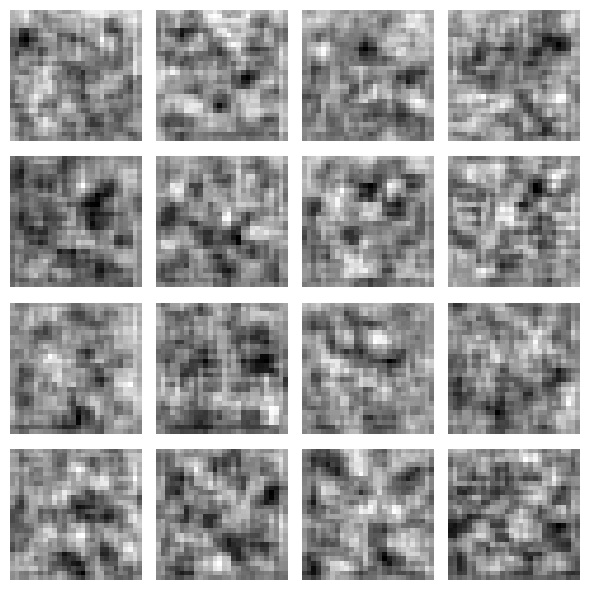



    ____________________ Epoch = 100 ____________________


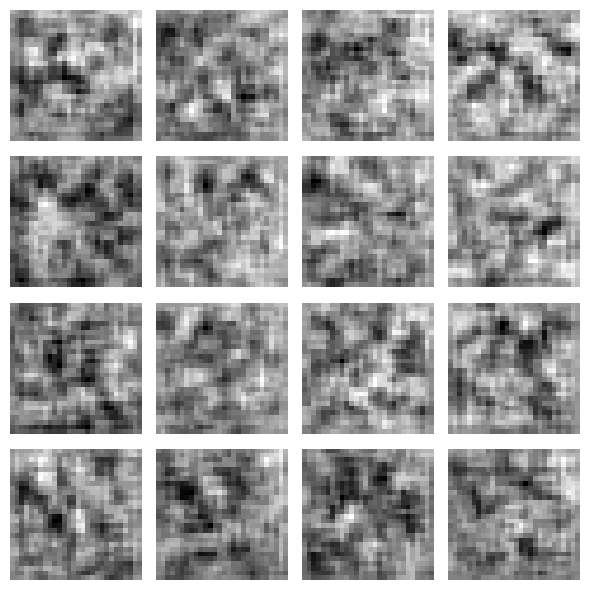



    ____________________ Epoch = 110 ____________________


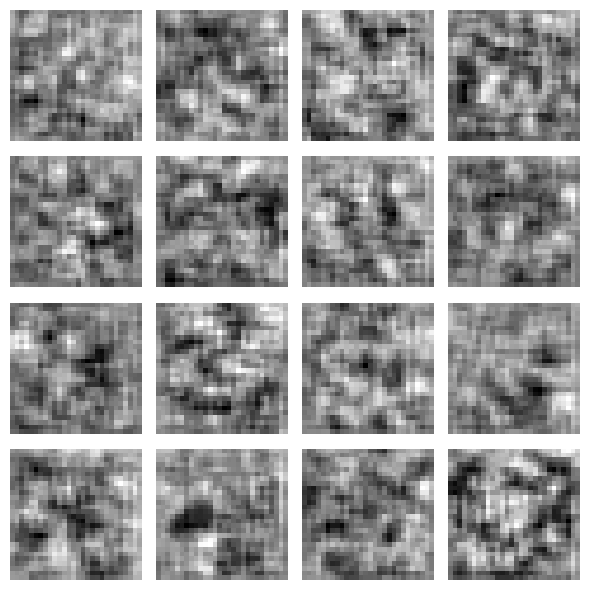

In [ ]:
# Visualizing results
i = 0
for i in range(len(samples)):
    images = samples[i].data.cpu().numpy()
    print("    ____________________ Epoch = %d ____________________" % (i * 10))
    plt.figure(figsize=(6, 6))
    for j in range(16):
        plt.subplot(4, 4, j+1)
        image = images[j, 0, :, :]
        plt.imshow(image, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    print("\n")

# Detailed Insights and Summary

### 1. Model Architecture
- **Generator**: We replaced `Conv2dTranspose` with `Upsample` + `Conv2d`. This is a crucial design choice in DCGANs to minimize 'checkerboard artifacts' that occur during deconvolution. The final `Tanh` layer is mandatory because the input images were normalized to a range of [-1, 1].
- **Discriminator**: This is a binary classifier that uses strided convolutions to downsample images. Including `Dropout` (0.3) is vital; it keeps the discriminator from becoming too powerful, which would then stop the generator from learning.

### 2. Loss Function and Training
- We use **Binary Cross Entropy (BCELoss)**. The 'adversarial' nature comes from the fact that the Generator is updated based on how well it fools the Discriminator (aiming for '1' labels), while the Discriminator is updated to correctly identify real vs. fake.

### 3. Hyperparameters
- **Learning Rate**: 0.0002 with Adam optimizer is a heuristic that works well for GANs.
- **Beta 1**: Set to 0.5 to provide a more stable training momentum.